In [1]:
# ================================================
# TASK 1: Exploring and Visualizing Iris Dataset
# ================================================
# Objective:
# Load, inspect, and visualize the Iris dataset
# to understand data trends and distributions.
#
# Dataset: Iris Dataset (loaded via seaborn)
#
# Tools Used: pandas, seaborn, matplotlib
# ================================================

In [2]:
# Step 1: Import karna zaroori libraries
# pandas - data load aur manipulate karne ke liye
# seaborn - beautiful plots banane ke liye
# matplotlib - base plotting engine

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Step 2: Dataset load karna
# seaborn ki built-in iris dataset use kar rahe hain
# df mein sara data store hoga

df = sns.load_dataset('iris')

# Pehli 5 rows dekhna - data kaisa dikhta hai
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Step 3: Dataset inspect karna
# Shape se pata chalta hai kitni rows aur columns hain
# Columns se pata chalta hai kaunse features hain

print("Shape of dataset:", df.shape)
print("Column names:", df.columns.tolist())

Shape of dataset: (150, 5)
Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [5]:
# Step 4: Dataset ki detailed info dekhna
# info() se pata chalta hai:
# - har column ka data type
# - kitni values hain (null toh nahi)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
# Step 5: Statistical summary dekhna
# describe() se pata chalta hai:
# - mean (average)
# - std (variation)
# - min/max (range)
# - 25%, 50%, 75% (data distribution)

df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
# Step 6: Missing values check karna
# Agar koi value missing hogi toh number show hoga
# 0 matlab koi missing value nahi - data clean hai

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


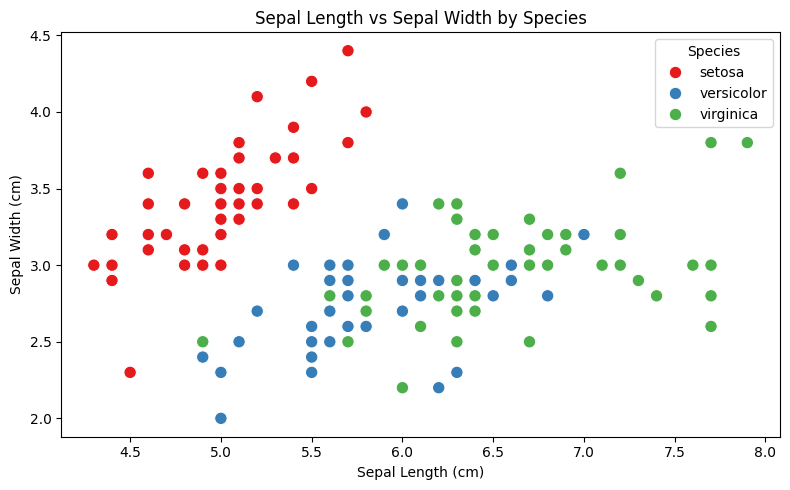

In [8]:
# Step 7: Scatter Plot banana
# Scatter plot se pata chalta hai:
# - Do features ka aapas mein kya relation hai
# - Kaunsi species alag hai aur kaunsi mix hai
# hue='species' se har species ka alag rang hoga

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species', palette='Set1', s=80)
plt.title('Sepal Length vs Sepal Width by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

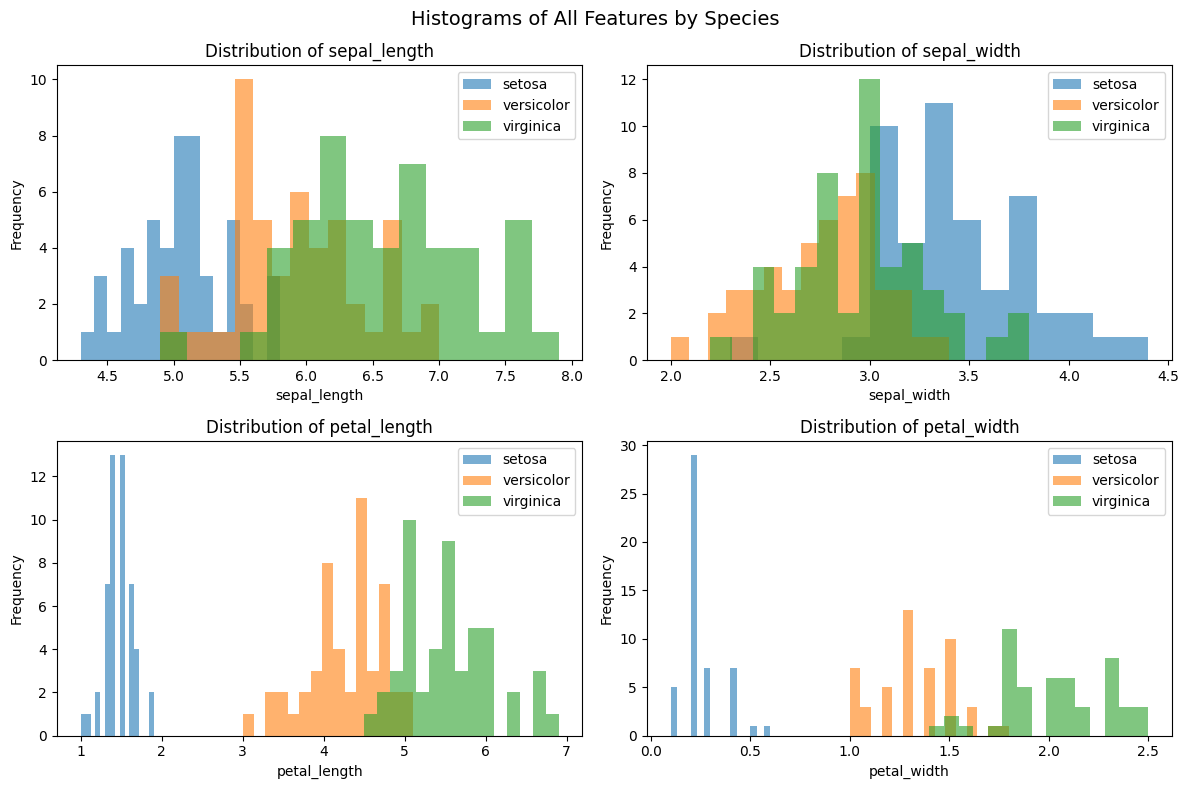

In [9]:
# Step 8: Histograms banana
# Histogram se pata chalta hai:
# - Har feature ki values kitni baar aayi hain
# - Kaunsi species ka data kahan concentrate hai
# 4 subplots hain - har feature ka alag graph

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    ax = axes[i // 2][i % 2]
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        ax.hist(subset[feature], alpha=0.6, label=species, bins=15)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Histograms of All Features by Species', fontsize=14)
plt.tight_layout()
plt.show()

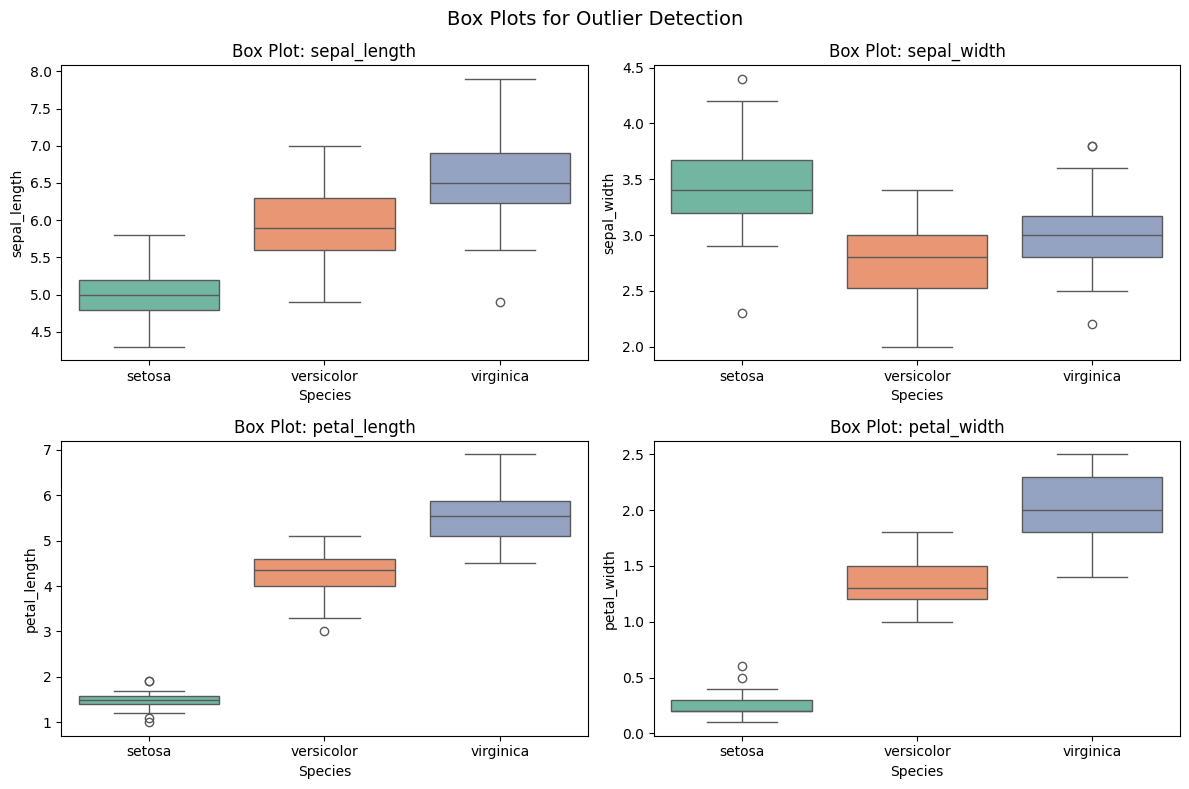

In [10]:
# Step 9: Box Plots banana
# Box plot se pata chalta hai:
# - Har feature ki normal range kya hai
# - Koi outlier (abnormal value) toh nahi
# - Har species ka data kaise spread hai

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, feature in enumerate(features):
    ax = axes[i // 2][i % 2]
    sns.boxplot(data=df, x='species', y=feature, hue='species', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'Box Plot: {feature}')
    ax.set_xlabel('Species')
    ax.set_ylabel(feature)

plt.suptitle('Box Plots for Outlier Detection', fontsize=14)
plt.tight_layout()
plt.show()

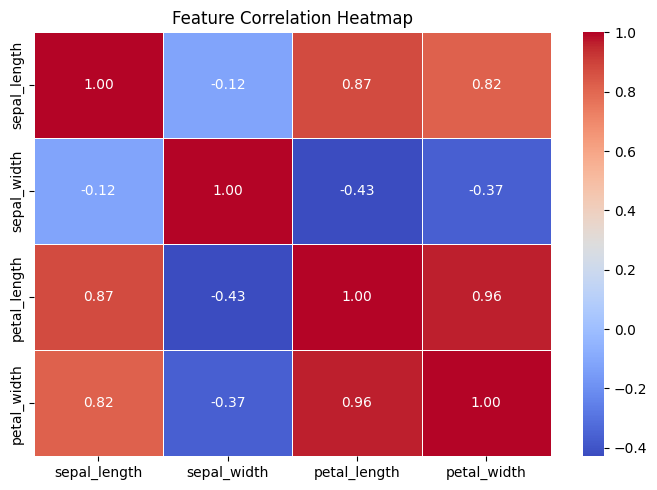

In [11]:
# Step 10: Heatmap banana
# Heatmap se pata chalta hai:
# - Do features ka aapas mein kitna relation hai
# - 1.0 = perfect relation, 0.0 = koi relation nahi
# - Lal rang = strong relation, Neela = ulta relation

plt.figure(figsize=(7, 5))
numeric_df = df.drop('species', axis=1)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [12]:
# Step 11: Final Insights
# Poori analysis ke baad yeh conclusions nikle

print("=== TASK 1 - FINAL INSIGHTS ===")
print()
print("1. Dataset has 150 flowers with 5 columns")
print("2. No missing values found - data is completely clean")
print("3. Setosa species is clearly separated from the other two")
print("4. Petal Length and Petal Width are the best features for identifying species")
print("5. Petal Length and Petal Width have a very strong correlation (0.96)")
print("6. Sepal Width has some outliers in Setosa species")
print()
print("=== ANALYSIS COMPLETE ===")

=== TASK 1 - FINAL INSIGHTS ===

1. Dataset has 150 flowers with 5 columns
2. No missing values found - data is completely clean
3. Setosa species is clearly separated from the other two
4. Petal Length and Petal Width are the best features for identifying species
5. Petal Length and Petal Width have a very strong correlation (0.96)
6. Sepal Width has some outliers in Setosa species

=== ANALYSIS COMPLETE ===
